<a href="https://colab.research.google.com/github/benishshrestha66/Projects/blob/main/W_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Install any missing libraries
!pip install plotly pandas openpyxl -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings ('ignore')

#pd.set_option ('display.float_format ', '{:, .2f}'.format)
#pd.set_option ('display.max_columns', 20)
#plt.rcParams['figure.figsize'] = (12,5)
#sns.set_theme(style = 'whitegrid')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving loan_file.csv to loan_file (1).csv


In [ ]:
df_raw = pd.read_csv("loan_file.csv")

print(f' File loaded successfully!')
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print()
print('First 5 rows (RAW — unclean data):')
df_raw.head()

 File loaded successfully!
Shape: 52,800 rows × 12 columns

First 5 rows (RAW — unclean data):


,Customer Name,Loan Amount,Interest Rate,Outstanding Principal,Outstanding Interest,Loan Type,Status,Late Days,Disbursement Date,Noise Column,Random Noise,Account Number
0,Hari Koirala,780353.23,15.61,571213.84,89166.48,Business,Overdue,60.0,2022-02-01,-0.31,0.132953,5618720407658803
1,Krishna Koirala,1213857.81,11.57,121355.33,14040.81,Personal,Overdue,74.0,2022-01-25,0.66,-0.007860,3037859455977839
2,NaN,1739043.48,12.81,1231369.00,NaN,NaN,Overdue,21.0,2022-06-06,-1.40,0.066710,7535379037110374
3,Hari Gurung,160002.58,13.78,150170.85,20693.54,Personal,Overdue,1.0,2021-04-27,0.16,0.093130,5695234308036075
4,Bikash Sharma,404558.69,9.47,123083.84,11656.04,Personal,Closed,NaN,2021-03-27,-1.26,-0.850451,9922671370527874


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52800 entries, 0 to 52799
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Name          46589 non-null  object 
 1   Loan Amount            46587 non-null  float64
 2   Interest Rate          46569 non-null  float64
 3   Outstanding Principal  46628 non-null  float64
 4   Outstanding Interest   46581 non-null  float64
 5   Loan Type              46597 non-null  object 
 6   Status                 46616 non-null  object 
 7   Late Days              46592 non-null  float64
 8   Disbursement Date      46602 non-null  object 
 9   Noise Column           49028 non-null  float64
 10  Random Noise           52800 non-null  float64
 11  Account Number         52800 non-null  int64  
dtypes: float64(7), int64(1), object(4)
memory usage: 4.8+ MB


In [ ]:
df_raw.describe()

,Loan Amount,Interest Rate,Outstanding Principal,Outstanding Interest,Late Days,Noise Column,Random Noise,Account Number
count,4.658700e+04,46569.000000,4.662800e+04,46581.000000,46592.000000,49028.000000,52800.000000,5.280000e+04
mean,1.045227e+06,11.992298,5.110514e+05,61454.394485,59.580336,-0.001995,0.000512,4.875052e+15
std,7.439874e+05,2.296930,4.365863e+05,54874.123086,34.691425,1.003191,1.000172,2.858325e+15
min,5.002128e+04,8.000000,1.644000e+01,2.130000,0.000000,-3.900000,-4.378253,1.000043e+15
25%,5.427643e+05,9.990000,1.510513e+05,17549.160000,29.000000,-0.680000,-0.671794,2.134926e+15
50%,1.028730e+06,11.980000,3.860630e+05,45223.660000,60.000000,-0.000000,-0.000552,4.756804e+15
75%,1.517607e+06,13.980000,7.775813e+05,91497.840000,90.000000,0.670000,0.680156,7.371745e+15
max,1.979945e+07,16.000000,1.972824e+06,302845.130000,119.000000,3.870000,4.223889,9.999092e+15


In [ ]:
df_raw.isnull().sum()

,0
Customer Name,6211
Loan Amount,6213
Interest Rate,6231
Outstanding Principal,6172
Outstanding Interest,6219
Loan Type,6203
Status,6184
Late Days,6208
Disbursement Date,6198
Noise Column,3772


In [ ]:
df_raw.isnull()

,Customer Name,Loan Amount,Interest Rate,Outstanding Principal,Outstanding Interest,Loan Type,Status,Late Days,Disbursement Date,Noise Column,Random Noise,Account Number
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
52795,False,False,False,False,False,False,False,False,False,False,False,False
52796,False,False,False,False,False,False,False,False,False,False,False,False
52797,False,False,False,False,False,False,False,False,False,False,False,False
52798,True,False,False,False,False,False,True,False,False,False,False,False


In [ ]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count':missing, 'Missing percentage':missing_pct})
missing_df = missing_df[missing_df['Missing Count']> 0].sort_values('Missing Count', ascending = False)
print(missing_df)

                       Missing Count  Missing percentage
Interest Rate                   6231                11.8
Outstanding Interest            6219                11.8
Loan Amount                     6213                11.8
Customer Name                   6211                11.8
Late Days                       6208                11.8
Loan Type                       6203                11.7
Disbursement Date               6198                11.7
Status                          6184                11.7
Outstanding Principal           6172                11.7
Noise Column                    3772                 7.1


In [ ]:
print('Loan Type:', df_raw['Loan Type'].unique())
print()
print('Status:', df_raw['Status'].unique())
print()

Loan Type: ['Business' 'Personal' nan 'Home' 'Auto']

Status: ['Overdue' 'Closed' nan 'Active' 'active' 'ACTIVE']



In [ ]:
# Working in copy to save our original file intact
dfcopy = df_raw.copy()
print(f'{dfcopy.shape}')

(52800, 12)


In [ ]:
dfcopy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52800 entries, 0 to 52799
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Name          46589 non-null  object 
 1   Loan Amount            46587 non-null  float64
 2   Interest Rate          46569 non-null  float64
 3   Outstanding Principal  46628 non-null  float64
 4   Outstanding Interest   46581 non-null  float64
 5   Loan Type              46597 non-null  object 
 6   Status                 46616 non-null  object 
 7   Late Days              46592 non-null  float64
 8   Disbursement Date      46602 non-null  object 
 9   Noise Column           49028 non-null  float64
 10  Random Noise           52800 non-null  float64
 11  Account Number         52800 non-null  int64  
dtypes: float64(7), int64(1), object(4)
memory usage: 4.8+ MB


In [ ]:
junk= ['Noise Column', 'Random Noise']
dfcopy.drop(columns=junk, inplace=True)
print(f'✅ Dropped junk: {junk}')
print(f'Remaining columns: {dfcopy.columns.tolist()}')

✅ Dropped junk: ['Noise Column', 'Random Noise']
Remaining columns: ['Customer Name', 'Loan Amount', 'Interest Rate', 'Outstanding Principal', 'Outstanding Interest', 'Loan Type', 'Status', 'Late Days', 'Disbursement Date', 'Account Number']


In [ ]:
print(f'Remaining columns: {dfcopy.columns}')

Remaining columns: Index(['Customer Name', 'Loan Amount', 'Interest Rate',
       'Outstanding Principal', 'Outstanding Interest', 'Loan Type', 'Status',
       'Late Days', 'Disbursement Date', 'Account Number'],
      dtype='object')


In [ ]:
dfcopy.index

RangeIndex(start=0, stop=52800, step=1)

In [ ]:
dfcopy['Status'] = dfcopy['Status'].str.strip().str.title()
print(dfcopy['Status'].value_counts())

Status
Active     15753
Closed     15548
Overdue    15315
Name: count, dtype: int64


In [ ]:
rows_before = len(dfcopy)

In [ ]:
critical_cols = ['Loan Amount', 'Outstanding Principal']
dfcopy.dropna(subset=critical_cols, inplace=True)

In [ ]:
dfcopy['Status'].fillna(dfcopy['Status'].mode() [0], inplace=True)
dfcopy['Loan Type'].fillna(dfcopy['Loan Type'].mode() [0], inplace=True)

In [ ]:
if dfcopy['Disbursement Date'].isna().any():
    dfcopy['Disbursement Date'].fillna(dfcopy['Disbursement Date'].mode()[0], inplace=True)
dfcopy['Outstanding Interest'].fillna(dfcopy['Outstanding Interest'].median(), inplace=True)


In [ ]:
dfcopy['Late Days'].fillna(0, inplace=True)

In [ ]:
dfcopy['Interest Rate'].fillna(dfcopy['Interest Rate'].median(), inplace=True)
dfcopy['Customer Name'].fillna('Unknown', inplace=True)

In [ ]:
rows_after = len(dfcopy)

print(f' Rows before: {rows_before:,} Rows after: {rows_after:,} Dropped: {rows_before - rows_after:,}')
print(f' Remaining missing values:')
print(dfcopy.isnull().sum())

 Rows before: 52,800 Rows after: 41,204 Dropped: 11,596
 Remaining missing values:
Customer Name            0
Loan Amount              0
Interest Rate            0
Outstanding Principal    0
Outstanding Interest     0
Loan Type                0
Status                   0
Late Days                0
Disbursement Date        0
Account Number           0
dtype: int64


In [ ]:
dfcopy['Disbursement Date'] = pd.to_datetime(dfcopy['Disbursement Date'])
dfcopy['Disbursement Year']  = dfcopy['Disbursement Date'].dt.year
dfcopy['Disbursement Month'] = dfcopy['Disbursement Date'].dt.month_name()

print(dfcopy[['Disbursement Date', 'Disbursement Year', 'Disbursement Month']].head(3))

  Disbursement Date  Disbursement Year Disbursement Month
0        2022-02-01               2022           February
1        2022-01-25               2022            January
2        2022-06-06               2022               June


In [ ]:
today = pd.Timestamp.today()
dfcopy['Loan Age (Days)'] = (today - dfcopy['Disbursement Date']).dt.days


In [ ]:
dfcopy['Total Outstanding'] = dfcopy['Outstanding Principal'] + dfcopy['Outstanding Interest']

In [ ]:
dfcopy['Repayment Ratio (%)'] = (
    (dfcopy['Loan Amount'] - dfcopy['Outstanding Principal']) / dfcopy['Loan Amount'] * 100).clip(0, 100).round(1)

In [ ]:
dfcopy['Risk Flag'] = dfcopy['Status'].apply(lambda x: 'At Risk' if x == 'Overdue' else 'Normal')

In [ ]:
dfcopy['Loan Size'] = pd.cut(
    dfcopy['Loan Amount'],
    bins=[0, 600_000, 1_200_000, 6_000_000, float('inf')],
    labels=['Small (< 6L)', 'Medium (6L-12L)', 'Large (12L-60L)', 'Very Large (> 60L)'])

In [ ]:
print(dfcopy[['Loan Amount', 'Total Outstanding', 'Repayment Ratio (%)', 'Risk Flag', 'Loan Size']].head(7))

   Loan Amount  Total Outstanding  Repayment Ratio (%) Risk Flag  \
0    780353.23          660380.32                 26.8   At Risk   
1   1213857.81          135396.14                 90.0   At Risk   
2   1739043.48         1276550.66                 29.2   At Risk   
3    160002.58          170864.39                  6.1   At Risk   
4    404558.69          134739.88                 69.6    Normal   
5     63779.30           36207.59                 47.5    Normal   
6    140998.04           38002.63                 76.7    Normal   

         Loan Size  
0  Medium (6L-12L)  
1  Large (12L-60L)  
2  Large (12L-60L)  
3     Small (< 6L)  
4     Small (< 6L)  
5     Small (< 6L)  
6     Small (< 6L)  


In [ ]:
print(f' Total Records   : {len(dfcopy):,}')
print(f' Columns         : {dfcopy.shape[1]}')
print(f' Missing Values  : {dfcopy.isnull().sum().sum()}')
print(f' Date Range      : {dfcopy["Disbursement Date"].min().date()} → {dfcopy["Disbursement Date"].max().date()}')
print(f' Loan Types      : {dfcopy["Loan Type"].unique().tolist()}')
print(f' Loan Statuses   : {dfcopy["Status"].unique().tolist()}')

 Total Records   : 41,204
 Columns         : 17
 Missing Values  : 0
 Date Range      : 2020-01-01 → 2024-02-09
 Loan Types      : ['Business', 'Personal', 'Home', 'Auto']
 Loan Statuses   : ['Overdue', 'Closed', 'Active']


In [ ]:
dfcopy.to_csv('loan_clean.csv', index=False)
print('Saved loan_clean.csv')



Saved loan_clean.csv


In [ ]:
dfcopy.to_excel('loan_clean.xlsx', index=False)
print('Saved: loan_clean.xlsx')


Saved: loan_clean.xlsx


In [ ]:
from google.colab import files

files.download('loan_clean.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
total_loans       = len(dfcopy)
total_disbursed   = dfcopy['Loan Amount'].sum()
total_outstanding = dfcopy['Total Outstanding'].sum()
avg_loan          = dfcopy['Loan Amount'].mean()
at_risk_count     = (dfcopy['Status'] == 'Overdue').sum()
at_risk_pct       = at_risk_count / total_loans * 100

print(f' Total Disbursed     : Rs. {total_disbursed/1e9:.2f} Billion')
print(f' Total Outstanding   : Rs. {total_outstanding/1e9:.2f} Billion')
print(f' Average Loan Size   : Rs. {avg_loan:,.0f}')
print(f' Overdue Loans       : {at_risk_count:,} ({at_risk_pct:.1f}%)')

 Total Disbursed     : Rs. 43.02 Billion
 Total Outstanding   : Rs. 23.49 Billion
 Average Loan Size   : Rs. 1,044,030
 Overdue Loans       : 11,957 (29.0%)


In [ ]:
status_counts = dfcopy['Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

fig = px.pie(
    status_counts,
    names='Status', values='Count',
    title='Loan Portfolio by Status',
    color='Status',
    color_discrete_map={'Active': '#2196F3', 'Overdue': '#F44336', 'Closed': '#4CAF50'},
    hole=0.2
)
fig.update_traces(textinfo='percent+label+value')
fig.update_layout(height=400)
fig.show()




In [ ]:
loan_type_stats = dfcopy.groupby('Loan Type').agg(
    Count=('Loan Amount', 'count'),
    Total_Disbursed=('Loan Amount', 'sum'),
    Avg_Loan=('Loan Amount', 'mean'),
    Avg_Interest_Rate=('Interest Rate', 'mean'),
    Total_Outstanding=('Total Outstanding', 'sum')
).reset_index().sort_values('Total_Disbursed', ascending=False)


In [ ]:
loan_type_stats['Total_Disbursed_Cr'] = (loan_type_stats['Total_Disbursed'] / 1e7).round(1)
loan_type_stats['Avg_Loan'] = loan_type_stats['Avg_Loan'].round(0)



In [ ]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Number of Loans by Type', 'Total Amount Disbursed (Crores)'))

fig.add_trace(go.Bar(
    x=loan_type_stats['Loan Type'], y=loan_type_stats['Count'],
    marker_color='#1976D2', name='Count',
    text=loan_type_stats['Count'], textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=loan_type_stats['Loan Type'], y=loan_type_stats['Total_Disbursed_Cr'],
    marker_color='#388E3C', name='Disbursed (Cr)',
    text=loan_type_stats['Total_Disbursed_Cr'].apply(lambda x: f'Rs.{x}Cr'),
    textposition='outside'
), row=1, col=2)

fig.update_layout(title=' Loan Type Analysis', height=450, showlegend=False)
fig.show()

print('Loan Type Summary:')
print(loan_type_stats[['Loan Type','Count','Total_Disbursed_Cr','Avg_Loan','Avg_Interest_Rate']].to_string(index=False))

Loan Type Summary:
Loan Type  Count  Total_Disbursed_Cr  Avg_Loan  Avg_Interest_Rate
 Personal  13978              1466.1 1048828.0          11.983663
     Auto   9075               948.9 1045600.0          12.006539
 Business   9023               944.8 1047151.0          11.948225
     Home   9128               942.0 1032037.0          12.033018


In [ ]:
fig = px.histogram(
    dfcopy, x='Interest Rate',
    color='Loan Type',
    title='Interest Rate Distribution by Loan Type',
    nbins=30,
    barmode='overlay',
    opacity=0.5,
    marginal='box'
)
fig.update_layout(height=480)
fig.show()
print('Average Interest Rate by Loan Type:')
print(dfcopy.groupby('Loan Type')['Interest Rate'].mean().round(2).to_string())

Average Interest Rate by Loan Type:
Loan Type
Auto        12.01
Business    11.95
Home        12.03
Personal    11.98


In [ ]:
fig = px.box(
    dfcopy, x='Loan Type', y='Loan Amount',
    color='Loan Type',
    title='Loan Amount Distribution by Type (Box Plot)',
    points=False
)
fig.update_layout(height=450, yaxis_title='Loan Amount (Rs.)', showlegend=False)
fig.show()

print('Loan Amount Statistics by Loan Type:')
print(dfcopy.groupby('Loan Type')['Loan Amount']
      .describe()[['min','25%','50%','mean','75%','max']]
      .applymap(lambda x: f'{x:,.0f}'))

Loan Amount Statistics by Loan Type:
              min      25%        50%       mean        75%         max
Loan Type                                                              
Auto       50,308  554,684  1,028,869  1,045,600  1,516,818  19,790,702
Business   50,469  539,783  1,035,054  1,047,151  1,515,794  18,634,615
Home       50,500  536,413  1,011,639  1,032,037  1,505,304  19,059,250
Personal   50,021  534,221  1,029,445  1,048,828  1,521,990  19,799,453


In [ ]:
yearly = dfcopy.groupby('Disbursement Year').agg(
    Loans=('Loan Amount', 'count'),
    Total_Disbursed=('Loan Amount', 'sum')
).reset_index()
yearly['Total_Disbursed_Cr'] = (yearly['Total_Disbursed'] / 1e7).round(1)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Number of Loans Disbursed Per Year',
                    'Total Amount Disbursed Per Year (Crores)'))

fig.add_trace(go.Bar(
    x=yearly['Disbursement Year'], y=yearly['Loans'],
    marker_color='#5C6BC0', name='Loans',
    text=yearly['Loans'], textposition='outside'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=yearly['Disbursement Year'], y=yearly['Total_Disbursed_Cr'],
    mode='lines+markers+text',
    marker=dict(size=10), line=dict(width=3, color='#E91E63'),
    text=yearly['Total_Disbursed_Cr'].apply(lambda x: f'{x}Cr'),
    textposition='top center', name='Amount'
), row=1, col=2)

fig.update_layout(title='Lending Trends Over Time', height=450, showlegend=False)
fig.show()

In [ ]:
overduedf = dfcopy[dfcopy['Status'] == 'Overdue'].copy()

overduedf['DPD Bucket'] = pd.cut(
    overduedf['Late Days'],
    bins=[0, 30, 60, 90, 180, float('inf')],
    labels=['1-30 days', '31-60 days', '61-90 days', '91-180 days', '180+ days']
)


dpd_summary = overduedf.groupby('DPD Bucket', observed=True).agg(
    Count=('Loan Amount', 'count'),
    Total_Outstanding=('Total Outstanding', 'sum')
).reset_index()
dpd_summary['Outstanding_Cr'] = (dpd_summary['Total_Outstanding'] / 1e7).round(1)

fig = px.bar(
    dpd_summary, x='DPD Bucket', y='Count',
    color='Outstanding_Cr',
    title='⚠️ Overdue Loans by Days Past Due (DPD)',
    text='Count',
    color_continuous_scale='Reds',
    labels={'Outstanding_Cr': 'Outstanding (Cr)'}
)
fig.update_traces(textposition='outside')
fig.update_layout(height=550)
fig.show()

print('DPD Bucket Summary:')
print(dpd_summary[['DPD Bucket','Count','Outstanding_Cr']].to_string(index=False))

DPD Bucket Summary:
 DPD Bucket  Count  Outstanding_Cr
  1-30 days   2621           149.6
 31-60 days   2596           149.9
 61-90 days   2581           148.0
91-180 days   2616           141.8


In [ ]:
repay_by_type = dfcopy.groupby('Loan Type')['Repayment Ratio (%)'].mean().reset_index()
repay_by_type.columns = ['Loan Type', 'Avg Repayment %']
repay_by_type = repay_by_type.sort_values('Avg Repayment %', ascending=True)

fig = px.bar(
    repay_by_type,
    x='Avg Repayment %', y='Loan Type',
    orientation='h',
    title='Average Repayment Progress by Loan Type (%)',
    text='Avg Repayment %',
    color='Avg Repayment %',color_continuous_scale='Greens'

)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=400, xaxis_range=[0, 100], showlegend=False)
fig.show()

In [ ]:
size_dist = dfcopy['Loan Size'].value_counts().reset_index()
size_dist.columns = ['Loan Size', 'Count']

size_outstanding = dfcopy.groupby('Loan Size', observed=True)['Total Outstanding'].sum().reset_index()
size_outstanding['Outstanding_Cr'] = (size_outstanding['Total Outstanding'] / 1e7).round(1)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Count by Loan Size', 'Total Outstanding by Loan Size (Cr)'))

fig.add_trace(go.Bar(
    x=size_dist['Loan Size'], y=size_dist['Count'],
    marker_color='green', name='Count',
    text=size_dist['Count'], textposition='outside'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=size_outstanding['Loan Size'], y=size_outstanding['Outstanding_Cr'],
    marker_color='blue', name='Outstanding',
    text=size_outstanding['Outstanding_Cr'].apply(lambda x: f'Rs.{x}Cr'),
    textposition='outside'
), row=1, col=2)

fig.update_layout(title='Portfolio Segmentation by Loan Size', height=550, showlegend=False)
fig.show()

In [ ]:
#DASHBOARD
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        'Portfolio Status Mix',
        'Disbursement by Loan Type (Cr)',
        'Overdue: DPD Buckets',
        'Lending Growth (Yearly)',
        'Avg Interest Rate by Type',
        'Repayment Progress by Type (%)'
    ],
    specs=[
        [{'type': 'pie'}, {'type': 'bar'}, {'type': 'bar'}],
        [{'type': 'scatter'}, {'type': 'bar'}, {'type': 'bar'}]
    ]
)

colors_status = {'Active':'#2196F3','Overdue':'#F44336','Closed':'#4CAF50'}

# 1 — Pie: Status
fig.add_trace(go.Pie(
    labels=status_counts['Status'],
    values=status_counts['Count'],
    hole=0.4,
    marker_colors=[colors_status.get(s,'#999') for s in status_counts['Status']],
    showlegend=False, textinfo='percent+label'
), row=1, col=1)

# 2 — Bar: Disbursed by loan type
fig.add_trace(go.Bar(
    x=loan_type_stats['Loan Type'],
    y=loan_type_stats['Total_Disbursed_Cr'],
    marker_color='#42A5F5', showlegend=False
), row=1, col=2)

# 3 — Bar: DPD Buckets
fig.add_trace(go.Bar(
    x=dpd_summary['DPD Bucket'],
    y=dpd_summary['Count'],
    marker_color='#EF5350', showlegend=False
), row=1, col=3)

# 4 — Line: Yearly Growth
fig.add_trace(go.Scatter(
    x=yearly['Disbursement Year'],
    y=yearly['Total_Disbursed_Cr'],
    mode='lines+markers',
    line=dict(color='#7E57C2', width=3),
    showlegend=False
), row=2, col=1)

# 5 — Bar: Avg Interest Rate
rate_by_type = dfcopy.groupby('Loan Type')['Interest Rate'].mean().reset_index()
fig.add_trace(go.Bar(
    x=rate_by_type['Loan Type'],
    y=rate_by_type['Interest Rate'].round(2),
    marker_color='#FF7043', showlegend=False
), row=2, col=2)

# 6 — Bar: Repayment
fig.add_trace(go.Bar(
    x=repay_by_type['Loan Type'],
    y=repay_by_type['Avg Repayment %'].round(1),
    marker_color='#26A69A', showlegend=False
), row=2, col=3)

fig.update_layout(
    title_text='LOAN PORTFOLIO EXECUTIVE DASHBOARD',
    title_font_size=20,
    height=700,
    template='plotly_white'
)
fig.show()

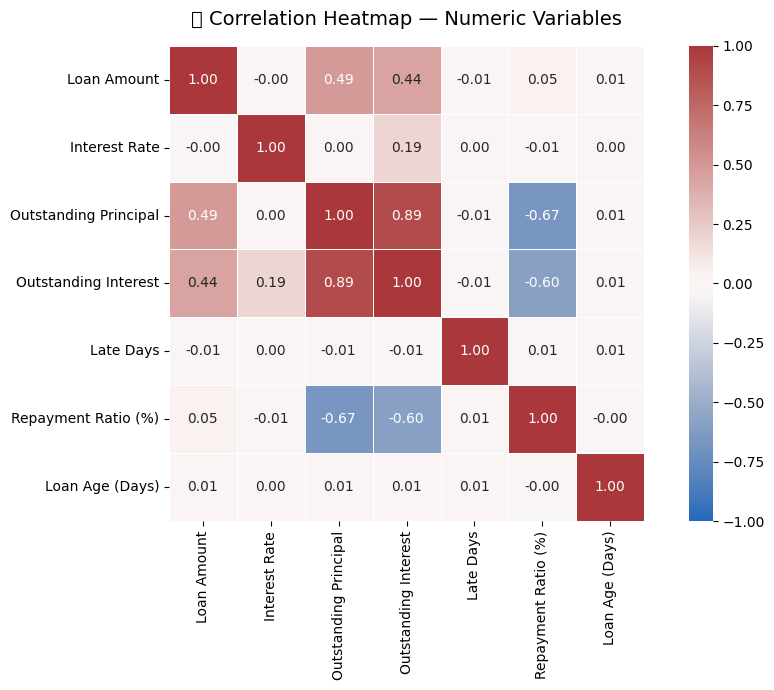

 Values close to +1 or -1 = strong relationship & Values near 0 = no relationship


In [ ]:
num_cols = ['Loan Amount', 'Interest Rate', 'Outstanding Principal',
            'Outstanding Interest', 'Late Days', 'Repayment Ratio (%)', 'Loan Age (Days)']

corr = dfcopy[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag',
            center=0, square=True, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('🔗 Correlation Heatmap — Numeric Variables', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print(' Values close to +1 or -1 = strong relationship & Values near 0 = no relationship')

In [ ]:
fig = px.scatter(
    dfcopy.sample(3000, random_state=50),
    x='Loan Amount', y='Outstanding Principal',
    color='Status',
    facet_col='Loan Type',
    title='💡 Loan Amount vs Outstanding Principal (by Status & Loan Type)',
    color_discrete_map={'Active':'#2196F3','Overdue':'#F44336','Closed':'#4CAF50'},
    opacity=0.5,
    trendline='ols'
)
fig.update_layout(height=450)
fig.show()

In [ ]:
overdue_pct = (dfcopy['Status'] == 'Overdue').mean() * 100
top_type = loan_type_stats.iloc[0]['Loan Type']
top_type_share = loan_type_stats.iloc[0]['Count'] / len(dfcopy) * 100
highest_rate_type = rate_by_type.loc[rate_by_type['Interest Rate'].idxmax(), 'Loan Type']
best_repay_type = repay_by_type.loc[repay_by_type['Avg Repayment %'].idxmax(), 'Loan Type']


print("KEY METRICS — LOAN PORTFOLIO")

print(f"1. Portfolio Risk (Overdue Loans): {overdue_pct:.1f}%")
print(f"2. Dominant Loan Type: {top_type} ({top_type_share:.1f}% of total loans)")
print(f"3. Loan Type with Highest Interest Rate: {highest_rate_type}")
print(f"4. Loan Type with Best Repayment Performance: {best_repay_type}")


KEY METRICS — LOAN PORTFOLIO
1. Portfolio Risk (Overdue Loans): 29.0%
2. Dominant Loan Type: Personal (33.9% of total loans)
3. Loan Type with Highest Interest Rate: Home
4. Loan Type with Best Repayment Performance: Home
